# Fase 4 — Embedding + FiLM + Decoder (nueva cabeza GAF)
Validación de `model/embedding.py`, `model/film.py` y la nueva cabeza de `model/decoder.py`

**Checks originales (embedding + FiLM):**
1. Summary del modelo de embedding
2. Forward pass del embedding → output `(batch, 64)`
3. Forward pass de FiLM → output shape == input shape
4. Prueba de identidad: gamma=1, beta=0 → feature map sin cambios

**Checks nuevos (decoder — GAFReconstructionLayer):**
5. Shape de salida `(batch, 14, 14, 3)`
6. Rango de valores en `[-1, 1]`
7. Diagonal de la imagen == salida de `diag_clip`
8. Triángulo superior GASF es simétrico

## 0. Setup

In [1]:
import sys
import os
sys.path.append('/app')  # raíz del proyecto dentro del contenedor

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from model.autoencoder import build_autoencoder

autoencoder, encoder, decoder, emb_model = build_autoencoder()
autoencoder.summary(line_length=90, expand_nested=False)

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
print('GPUs disponibles:', gpus)
assert len(gpus) > 0, '❌ No se detectó GPU. Verificar Docker y CUDA.'
print('✅ GPU OK')

2026-04-10 23:12:00.664698: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 23:12:00.664746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 23:12:00.665721: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Model: "gaf_autoencoder"
__________________________________________________________________________________________
 Layer (type)              Output Shape               Param   Connected to                
                                                       #                                  
 gaf_input (InputLayer)    [(None, 90, 90, 3)]        0       []                          
                                                                                          
 local_idx (InputLayer)    [(None,)]                  0       []                          
                                                                                          
 producto_idx (InputLayer  [(None,)]                  0       []                          
 )                                                                                        
                                                                                          
 encoder (Functional)      (None, 3, 3, 1280)         40495   ['g

In [2]:
from config import (
    NUM_LOCALES, NUM_PRODUCTOS,
    LOCAL_EMB_DIM, PRODUCTO_EMB_DIM,
    EMB_MLP_HIDDEN, EMB_OUTPUT_DIM, EMB_DROPOUT,
)

print('── Config de embeddings ──────────────────')
print(f'  NUM_LOCALES      = {NUM_LOCALES}')
print(f'  NUM_PRODUCTOS    = {NUM_PRODUCTOS}')
print(f'  LOCAL_EMB_DIM    = {LOCAL_EMB_DIM}')
print(f'  PRODUCTO_EMB_DIM = {PRODUCTO_EMB_DIM}')
print(f'  EMB_MLP_HIDDEN   = {EMB_MLP_HIDDEN}')
print(f'  EMB_OUTPUT_DIM   = {EMB_OUTPUT_DIM}')
print(f'  EMB_DROPOUT      = {EMB_DROPOUT}')


total      = autoencoder.count_params()
trainable  = sum(tf.size(v).numpy() for v in autoencoder.trainable_variables)
frozen     = total - trainable

print(f"Total parámetros    : {total:>12,}")
print(f"Entrenables         : {trainable:>12,}")
print(f"Congelados (encoder): {frozen:>12,}")
assert frozen > 0, "❌ El encoder debería estar congelado en Fase 1"
print("✅ Encoder congelado correctamente")

── Config de embeddings ──────────────────
  NUM_LOCALES      = 1200
  NUM_PRODUCTOS    = 200
  LOCAL_EMB_DIM    = 32
  PRODUCTO_EMB_DIM = 64
  EMB_MLP_HIDDEN   = 128
  EMB_OUTPUT_DIM   = 64
  EMB_DROPOUT      = 0.1
Total parámetros    :    7,565,379
Entrenables         :    3,515,040
Congelados (encoder):    4,050,339
✅ Encoder congelado correctamente


## 1. Embedding model — summary

In [3]:
from model.embedding import build_embedding_model

embedding_model = build_embedding_model()
embedding_model.summary(line_length=80)

Model: "embedding_model"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 local_idx (InputLayer  [(None,)]               0       []                      
 )                                                                              
                                                                                
 producto_idx (InputLa  [(None,)]               0       []                      
 yer)                                                                           
                                                                                
 local_embedding (Embe  (None, 32)              38400   ['local_idx[0][0]']     
 dding)                                                                         
                                                                                
 pr

In [4]:
import numpy as np

batch = 4
gaf_in   = np.random.uniform(-1, 1, size=(batch, 90, 90, 3)).astype("float32")
local_i  = np.random.randint(0, 50,  size=(batch,))
prod_i   = np.random.randint(0, 500, size=(batch,))

gaf_pred = autoencoder([gaf_in, local_i, prod_i], training=False)

print(f"Input shape : {gaf_in.shape}")
print(f"Output shape: {gaf_pred.shape}")
assert gaf_pred.shape == (batch, 14, 14, 3), f"❌ Shape incorrecto: {gaf_pred.shape}"
print("✅ Forward pass completo sin errores")
print(f"Rango output: [{gaf_pred.numpy().min():.3f}, {gaf_pred.numpy().max():.3f}]")
print("(Esperado: dentro de [-1, 1] por softsign/GAFReconstructionLayer)")

Input shape : (4, 90, 90, 3)
Output shape: (4, 14, 14, 3)
✅ Forward pass completo sin errores
Rango output: [-1.000, 0.277]
(Esperado: dentro de [-1, 1] por softsign/GAFReconstructionLayer)


In [5]:
# Verificar parámetros esperados
total_params = embedding_model.count_params()
print(f'Total parámetros: {total_params:,}')

# Cálculo manual esperado:
# local_embedding:    NUM_LOCALES   * LOCAL_EMB_DIM
# producto_embedding: NUM_PRODUCTOS * PRODUCTO_EMB_DIM
# mlp_hidden:         (LOCAL_EMB_DIM + PRODUCTO_EMB_DIM) * EMB_MLP_HIDDEN + EMB_MLP_HIDDEN
# mlp_output:         EMB_MLP_HIDDEN * EMB_OUTPUT_DIM + EMB_OUTPUT_DIM
expected = (
    NUM_LOCALES * LOCAL_EMB_DIM +
    NUM_PRODUCTOS * PRODUCTO_EMB_DIM +
    (LOCAL_EMB_DIM + PRODUCTO_EMB_DIM) * EMB_MLP_HIDDEN + EMB_MLP_HIDDEN +
    EMB_MLP_HIDDEN * EMB_OUTPUT_DIM + EMB_OUTPUT_DIM
)
print(f'Parámetros esperados: {expected:,}')
assert total_params == expected, f'❌ Mismatch: {total_params} vs {expected}'
print('✅ Parámetros correctos')

Total parámetros: 71,872
Parámetros esperados: 71,872
✅ Parámetros correctos


## 2. Forward pass del embedding

In [6]:
BATCH_SIZE = 8
np.random.seed(42)

# Índices enteros aleatorios dentro del rango válido
local_idx    = np.random.randint(0, NUM_LOCALES,   size=(BATCH_SIZE,))
producto_idx = np.random.randint(0, NUM_PRODUCTOS, size=(BATCH_SIZE,))

print(f'local_idx shape:    {local_idx.shape}  → {local_idx}')
print(f'producto_idx shape: {producto_idx.shape}  → {producto_idx}')

local_idx shape:    (8,)  → [1126  860 1130 1095 1044  121  466  330]
producto_idx shape: (8,)  → [ 87 116  99 103 151 130 149  52]


In [7]:
embedding_output = embedding_model([local_idx, producto_idx], training=False)

print(f'Output shape: {embedding_output.shape}')
assert embedding_output.shape == (BATCH_SIZE, EMB_OUTPUT_DIM), \
    f'❌ Shape incorrecto: {embedding_output.shape}'
print(f'✅ Embedding output shape correcto: (batch={BATCH_SIZE}, dim={EMB_OUTPUT_DIM})')

print(f'\nRango de valores — min: {embedding_output.numpy().min():.4f}, max: {embedding_output.numpy().max():.4f}')
print('(Esperado: >= 0 por ReLU en la última capa)')

Output shape: (8, 64)
✅ Embedding output shape correcto: (batch=8, dim=64)

Rango de valores — min: 0.0000, max: 0.0710
(Esperado: >= 0 por ReLU en la última capa)


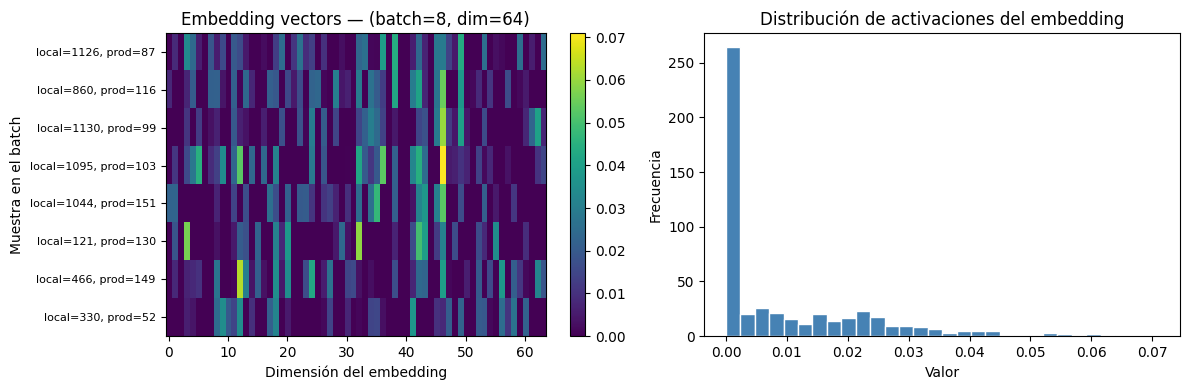

Imagen guardada en outputs/visualizations/fase4_embedding_output.png


In [8]:
# Visualizar distribución de los vectores de embedding
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(embedding_output.numpy(), aspect='auto', cmap='viridis')
axes[0].set_title(f'Embedding vectors — (batch={BATCH_SIZE}, dim={EMB_OUTPUT_DIM})')
axes[0].set_xlabel('Dimensión del embedding')
axes[0].set_ylabel('Muestra en el batch')
axes[0].set_yticks(range(BATCH_SIZE))
axes[0].set_yticklabels([f'local={l}, prod={p}' for l, p in zip(local_idx, producto_idx)], fontsize=8)
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].hist(embedding_output.numpy().flatten(), bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de activaciones del embedding')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase4_embedding_output.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imagen guardada en outputs/visualizations/fase4_embedding_output.png')

## 3. FiLM — forward pass y verificación de shape

In [9]:
from model.film import FiLMBlock

# Simular un feature map típico del decoder
# Ejemplo: bloque intermedio con H=45, W=45, C=128
H, W, C = 45, 45, 128

feature_map = tf.random.normal(shape=(BATCH_SIZE, H, W, C))
print(f'Feature map shape: {feature_map.shape}  (batch, H, W, C)')
print(f'Embedding shape:   {embedding_output.shape}  (batch, emb_dim)')

Feature map shape: (8, 45, 45, 128)  (batch, H, W, C)
Embedding shape:   (8, 64)  (batch, emb_dim)


In [10]:
film_block = FiLMBlock(num_channels=C, name='film_test')

modulated = film_block(feature_map, embedding_output)

print(f'Input shape:  {feature_map.shape}')
print(f'Output shape: {modulated.shape}')
assert modulated.shape == feature_map.shape, \
    f'❌ Shape cambió: {feature_map.shape} → {modulated.shape}'
print('✅ FiLM no cambia el shape del feature map')

# Parámetros de este bloque FiLM
film_params = sum([tf.size(v).numpy() for v in film_block.trainable_variables])
print(f'\nParámetros de este FiLMBlock: {film_params:,}')
expected_film = (EMB_OUTPUT_DIM * C + C) * 2  # gamma + beta, cada uno con bias
print(f'Esperado: {expected_film:,}  (2 × [emb_dim×C + C])')
assert film_params == expected_film, f'❌ Mismatch: {film_params} vs {expected_film}'
print('✅ Parámetros FiLM correctos')

Input shape:  (8, 45, 45, 128)
Output shape: (8, 45, 45, 128)
✅ FiLM no cambia el shape del feature map

Parámetros de este FiLMBlock: 16,640
Esperado: 16,640  (2 × [emb_dim×C + C])
✅ Parámetros FiLM correctos


## 4. Prueba de identidad — gamma=1, beta=0

In [11]:
# Crear un FiLMBlock con pesos forzados a identidad
film_identity = FiLMBlock(num_channels=C, name='film_identity')

# Inicializar con un forward pass para crear los pesos
_ = film_identity(feature_map, embedding_output)

# Forzar gamma_proj: weights=0, bias=1  → siempre produce gamma=1
# Forzar beta_proj:  weights=0, bias=0  → siempre produce beta=0
film_identity.gamma_proj.set_weights([
    np.zeros((EMB_OUTPUT_DIM, C)),  # kernel
    np.ones(C),                     # bias = 1
])
film_identity.beta_proj.set_weights([
    np.zeros((EMB_OUTPUT_DIM, C)),  # kernel
    np.zeros(C),                    # bias = 0
])

identity_output = film_identity(feature_map, embedding_output)

max_diff = tf.reduce_max(tf.abs(identity_output - feature_map)).numpy()
print(f'Diferencia máxima (gamma=1, beta=0): {max_diff:.2e}')
assert max_diff < 1e-5, f'❌ FiLM identidad falla: diff={max_diff}'
print('✅ Con gamma=1 y beta=0, FiLM devuelve el feature map sin cambios')

Diferencia máxima (gamma=1, beta=0): 0.00e+00
✅ Con gamma=1 y beta=0, FiLM devuelve el feature map sin cambios


## 5. Verificar que distintos locales/productos generan modulaciones distintas

In [12]:
# Mismo feature map, distintas identidades → distintos outputs
single_map = tf.random.normal(shape=(1, H, W, C), seed=0)

idxs = [(0, 0), (0, 100), (10, 0), (10, 100)]
outputs = []

for local, prod in idxs:
    emb = embedding_model(
        [np.array([local]), np.array([prod])], training=False
    )
    out = film_block(single_map, emb)
    outputs.append(out.numpy())

print('Diferencias entre modulaciones (mismo feature map, distinta identidad):')
labels = [f'local={l}, prod={p}' for l, p in idxs]
for i in range(len(idxs)):
    for j in range(i+1, len(idxs)):
        diff = np.abs(outputs[i] - outputs[j]).mean()
        print(f'  {labels[i]} vs {labels[j]}: mean_diff={diff:.4f}')

print('\n✅ Identidades distintas producen modulaciones distintas' if diff > 0 else '❌ Las modulaciones son idénticas — revisar embedding')

Diferencias entre modulaciones (mismo feature map, distinta identidad):
  local=0, prod=0 vs local=0, prod=100: mean_diff=0.0105
  local=0, prod=0 vs local=10, prod=0: mean_diff=0.0109
  local=0, prod=0 vs local=10, prod=100: mean_diff=0.0105
  local=0, prod=100 vs local=10, prod=0: mean_diff=0.0150
  local=0, prod=100 vs local=10, prod=100: mean_diff=0.0094
  local=10, prod=0 vs local=10, prod=100: mean_diff=0.0106

✅ Identidades distintas producen modulaciones distintas


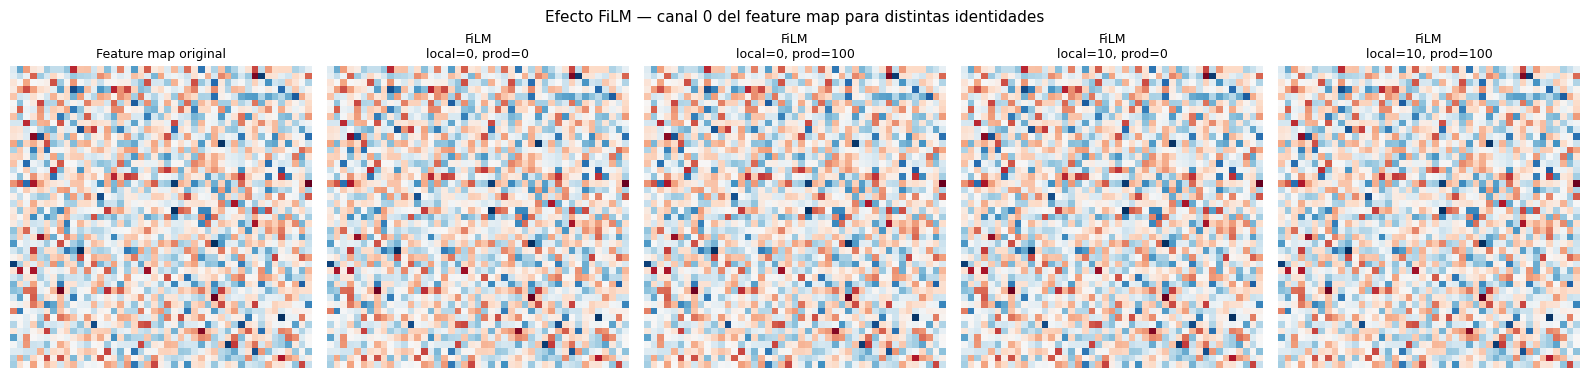

Imagen guardada en outputs/visualizations/fase4_film_effect.png


In [13]:
# Visualizar efecto de FiLM en un canal del feature map
canal = 0  # primer canal
fig, axes = plt.subplots(1, len(idxs) + 1, figsize=(16, 4))

axes[0].imshow(single_map.numpy()[0, :, :, canal], cmap='RdBu_r', vmin=-3, vmax=3)
axes[0].set_title('Feature map original', fontsize=9)
axes[0].axis('off')

for i, (label, out) in enumerate(zip(labels, outputs)):
    axes[i+1].imshow(out[0, :, :, canal], cmap='RdBu_r', vmin=-3, vmax=3)
    axes[i+1].set_title(f'FiLM\n{label}', fontsize=9)
    axes[i+1].axis('off')

plt.suptitle('Efecto FiLM — canal 0 del feature map para distintas identidades', fontsize=11)
plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase4_film_effect.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imagen guardada en outputs/visualizations/fase4_film_effect.png')

## Resumen de validación

In [14]:
print('══════════════════════════════════════════════')
print('  FASE 4 — Resumen de validación')
print('══════════════════════════════════════════════')
print(f'  Embedding output shape : (batch, {EMB_OUTPUT_DIM})  ✅')
print(f'  FiLM preserva shape    : (batch, H, W, C)  ✅')
print(f'  Prueba de identidad    : passed  ✅')
print(f'  Modulación diferencial : passed  ✅')
print('══════════════════════════════════════════════')
print()
print('→ Listo para avanzar a Fase 5: Encoder + Decoder')
print('→ Antes de avanzar, pega este output en Claude.ai')

══════════════════════════════════════════════
  FASE 4 — Resumen de validación
══════════════════════════════════════════════
  Embedding output shape : (batch, 64)  ✅
  FiLM preserva shape    : (batch, H, W, C)  ✅
  Prueba de identidad    : passed  ✅
  Modulación diferencial : passed  ✅
══════════════════════════════════════════════

→ Listo para avanzar a Fase 5: Encoder + Decoder
→ Antes de avanzar, pega este output en Claude.ai


---
## 6. Validación — Nueva cabeza del decoder (GAFReconstructionLayer)

Verifica los 4 contratos del nuevo `decoder.py`:
1. Shape de salida `(batch, 14, 14, 3)`
2. Todos los valores en `[-1, 1]`
3. La diagonal de la imagen == salida de `diag_clip` (mismo forward pass)
4. Construcción GAF híbrida correcta: GASF arriba `cos(φᵢ+φⱼ)`, GADF abajo `sin(φᵢ-φⱼ)`

In [15]:
# ── Setup: un único forward pass que expone imagen + diagonal ────────────────
import importlib
import model.decoder
importlib.reload(model.decoder)

from model.autoencoder import build_autoencoder
import tensorflow as tf
import numpy as np

autoencoder, encoder, decoder, emb_model = build_autoencoder(encoder_trainable=False)

batch = 4
gaf_in = tf.random.uniform((batch, 90, 90, 3), -1, 1)
loc    = tf.zeros((batch,), dtype=tf.int32)
prod   = tf.zeros((batch,), dtype=tf.int32)

# Modelo dual: [imagen_final, diag_clip] en un solo forward pass
# Evita no-determinismo por Dropout/BN al comparar salidas de dos forward passes distintos
diag_clip_tensor = decoder.get_layer('diag_clip').output
decoder_dual = tf.keras.Model(
    inputs=decoder.input,
    outputs=[decoder.output, diag_clip_tensor]
)

bottleneck = encoder(gaf_in, training=False)
emb        = emb_model([loc, prod], training=False)
out, diag_pred = decoder_dual([bottleneck, emb], training=False)
out_np = out.numpy()

print(f'Shape imagen  : {out.shape}')
print(f'Shape diagonal: {diag_pred.shape}')
print(f'dtype imagen  : {out.dtype}')
print(f'dtype diagonal: {diag_pred.dtype}')

Shape imagen  : (4, 14, 14, 3)
Shape diagonal: (4, 14, 3)
dtype imagen  : <dtype: 'float32'>
dtype diagonal: <dtype: 'float32'>


In [16]:
# ── CHECK 1: Shape ────────────────────────────────────────────────────────────
assert out.shape == (batch, 14, 14, 3), f'❌ Shape incorrecto: {out.shape}'
print(f'✅ CHECK 1 — Shape correcto: {out.shape}')

✅ CHECK 1 — Shape correcto: (4, 14, 14, 3)


In [17]:
# ── CHECK 2: Rango de valores ─────────────────────────────────────────────────
vmin, vmax = out_np.min(), out_np.max()
assert vmin >= -1.0 - 1e-5 and vmax <= 1.0 + 1e-5, \
    f'❌ Valores fuera de [-1, 1]: [{vmin:.4f}, {vmax:.4f}]'
print(f'✅ CHECK 2 — Rango correcto: [{vmin:.4f}, {vmax:.4f}]')

✅ CHECK 2 — Rango correcto: [-1.0000, 0.1949]


In [18]:
# ── CHECK 3: Diagonal imagen == salida de diag_clip ──────────────────────────
# Ambas salidas provienen del mismo forward pass → comparación válida
diag_image = tf.transpose(
    tf.linalg.diag_part(tf.transpose(out, [0, 3, 1, 2])),
    [0, 2, 1]
)  # (batch, 14, 3)

max_diff = np.abs(diag_pred.numpy() - diag_image.numpy()).max()
print(f'Diferencia máx diagonal vs imagen: {max_diff:.2e}')
assert max_diff < 1e-5, f'❌ Diagonal no coincide — max diff: {max_diff:.2e}'
print(f'✅ CHECK 3 — Diagonal exacta (max_diff={max_diff:.2e})')

Diferencia máx diagonal vs imagen: 0.00e+00
✅ CHECK 3 — Diagonal exacta (max_diff=0.00e+00)


In [19]:
# ── CHECK 4: Construcción GAF híbrida correcta ────────────────────────────────
# Triángulo superior (i<j): cos(φᵢ+φⱼ)  — GASF
# Triángulo inferior (i>j): sin(φᵢ-φⱼ)  — GADF
# Diagonal (i==j):          diag_clip[i] — valor directo
# Nota: el triángulo superior NO es espejo del inferior (son funciones distintas)
T = 14
all_ok = True

for c in range(3):
    for b in range(batch):
        img      = out_np[b, :, :, c]
        diag_vals = diag_pred.numpy()[b, :, c]
        phi      = np.arccos(np.clip(diag_vals, -1, 1))

        for i in range(T):
            for j in range(T):
                if i < j:
                    expected = np.cos(phi[i] + phi[j])
                    if abs(img[i, j] - expected) > 1e-4:
                        print(f'  ❌ GASF canal={c} batch={b} [{i},{j}]: '
                              f'got={img[i,j]:.4f} expected={expected:.4f}')
                        all_ok = False
                elif i > j:
                    expected = np.sin(phi[i] - phi[j])
                    if abs(img[i, j] - expected) > 1e-4:
                        print(f'  ❌ GADF canal={c} batch={b} [{i},{j}]: '
                              f'got={img[i,j]:.4f} expected={expected:.4f}')
                        all_ok = False

assert all_ok, '❌ CHECK 4 fallido — imagen GAF no respeta la construcción híbrida'
print('✅ CHECK 4 — Imagen GAF híbrida correcta (GASF arriba, GADF abajo)')

✅ CHECK 4 — Imagen GAF híbrida correcta (GASF arriba, GADF abajo)


In [20]:
# ── Resumen ───────────────────────────────────────────────────────────────────
print('══════════════════════════════════════════════════════════════')
print('  FASE 4 (nueva cabeza) — Resumen de validación')
print('══════════════════════════════════════════════════════════════')
print(f'  CHECK 1 — Shape salida         : {out.shape}  ✅')
print(f'  CHECK 2 — Rango [-1,1]          : [{vmin:.4f}, {vmax:.4f}]  ✅')
print(f'  CHECK 3 — Diagonal exacta       : max_diff={max_diff:.2e}  ✅')
print( '  CHECK 4 — Construcción GAF híbr.: ✅')
print('══════════════════════════════════════════════════════════════')
print()
print('→ Nuevo decoder validado. Listo para smoke test con train.py.')
print('→ Pega este output en Claude.ai antes de entrenar.')

══════════════════════════════════════════════════════════════
  FASE 4 (nueva cabeza) — Resumen de validación
══════════════════════════════════════════════════════════════
  CHECK 1 — Shape salida         : (4, 14, 14, 3)  ✅
  CHECK 2 — Rango [-1,1]          : [-1.0000, 0.1949]  ✅
  CHECK 3 — Diagonal exacta       : max_diff=0.00e+00  ✅
  CHECK 4 — Construcción GAF híbr.: ✅
══════════════════════════════════════════════════════════════

→ Nuevo decoder validado. Listo para smoke test con train.py.
→ Pega este output en Claude.ai antes de entrenar.
